# Kalibrasi Skenario Hybrid NLP Tanpa LLM
Notebook ini menjadi alur presentasi. Logic utama tetap berada di folder `services/` agar mudah dipindahkan ke `main.py`.


In [1]:
from pathlib import Path
import sys

import polars as pl
from IPython.display import display


def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in (current, *current.parents):
        if (candidate / "config.py").exists() and (candidate / "services").is_dir():
            return candidate
    raise FileNotFoundError("Root proyek tidak ditemukan")


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import config
from services.ambiguity_service import AmbiguityService
from services.artifact_service import ArtifactService
from services.clustering_service import ClusteringService
from services.dataset_service import DatasetService
from services.embedding_service import EmbeddingService
from services.evaluation_service import EvaluationService
from services.lexicon_sentiment_service import LexiconSentimentService
from services.preprocessing_service import PreprocessingService
from services.visualization_service import VisualizationService

pl.Config.set_tbl_hide_column_data_types(True)
pl.Config.set_tbl_cell_alignment("LEFT")
pl.Config.set_fmt_str_lengths(10_000)
pl.Config.set_tbl_width_chars(10_000)
pl.Config.set_tbl_cols(-1)
pl.Config.set_tbl_rows(20)


polars.config.Config

## 1. Konfigurasi Dataset


In [2]:
DATASET_PATH = config.DATASETS / "tokopedia-product-reviews-2019.csv"
OUTPUT_DATASET_PATH = config.CALIBRATION_DATASET_PATH
OUTPUT_SUMMARY_PATH = config.CALIBRATION_SUMMARY_PATH
OUTPUT_RESULTS_PATH = config.NON_LLM_RESULTS_PATH
OUTPUT_METRICS_PATH = config.NON_LLM_METRICS_PATH

RANDOM_SEED = 42
SOURCE_NAME = "tokopedia"
MAX_ROWS = 2_000  # ubah ke None jika ingin menjalankan seluruh dataset

print(f"Dataset: {DATASET_PATH}")
print(f"Batas baris demo: {MAX_ROWS if MAX_ROWS else 'semua'}")


Dataset: E:\School\tugas-akhir\project\datasets\tokopedia-product-reviews-2019.csv
Batas baris demo: 2000


## 2. Load, Adaptasi Kolom, Validasi


Baris sumber: 40,607
Baris digunakan: 2,000
{'total_rows': 2000, 'required_columns': ['id', 'source', 'text'], 'missing_columns': [], 'null_text': 0, 'empty_text': 0, 'empty_source': 0, 'is_valid': True, 'issues': []}


{'total_data': 2000,
 'distribusi_sumber': {'tokopedia': 2000},
 'jumlah_data_kosong': 0,
 'jumlah_duplikat': 59,
 'rata_rata_panjang_teks': 54.75}

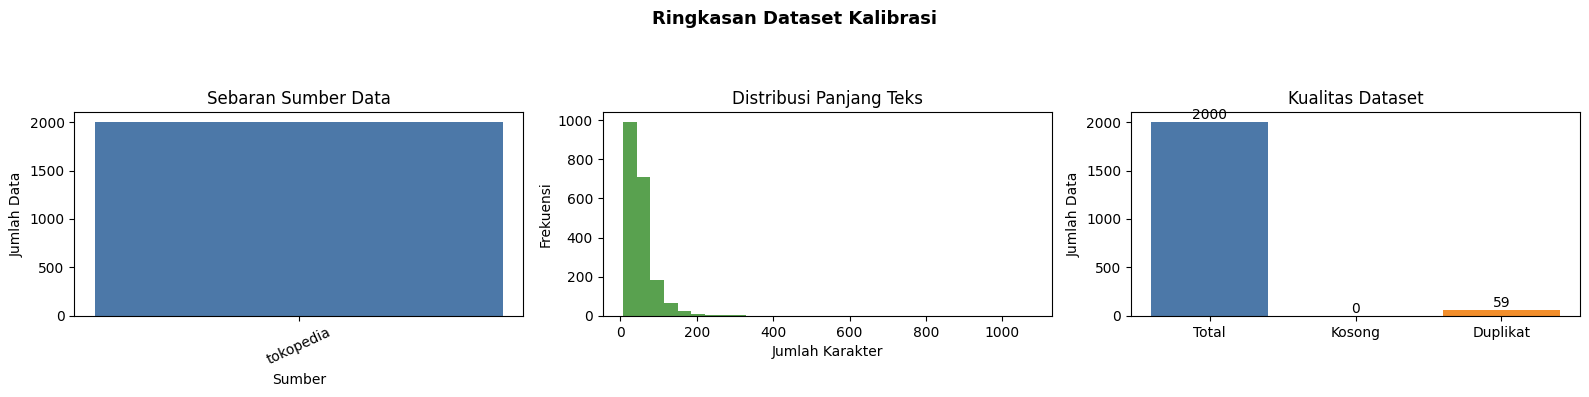

In [3]:
dataset_service = DatasetService()
evaluation_service = EvaluationService()
artifact_service = ArtifactService()
visualization_service = VisualizationService()

raw_df = dataset_service.load(DATASET_PATH)
if config.COL_TEXT not in raw_df.columns:
    raise KeyError(f"Kolom '{config.COL_TEXT}' tidak ditemukan pada dataset")
if "rating" not in raw_df.columns:
    raise KeyError("Kolom 'rating' dibutuhkan sebagai label aktual kalibrasi")

base_df = raw_df
if MAX_ROWS is not None:
    base_df = base_df.head(MAX_ROWS)

text_df = (
    base_df
    .select(config.COL_TEXT, "rating")
    .with_row_index(config.COL_ID, offset=1)
    .with_columns(
        pl.col(config.COL_ID).cast(pl.Utf8),
        pl.lit(SOURCE_NAME).alias(config.COL_SOURCE),
        pl.col(config.COL_TEXT).cast(pl.Utf8, strict=False),
    )
    .select(config.COL_ID, config.COL_SOURCE, config.COL_TEXT, "rating")
)
text_df = evaluation_service.add_actual_label_from_rating(text_df)

validation = dataset_service.validate(text_df)
summary = dataset_service.build_summary(text_df)

print(f"Baris sumber: {raw_df.height:,}")
print(f"Baris digunakan: {text_df.height:,}")
print(validation)
display(summary)
fig_dataset = visualization_service.plot_dataset_overview(text_df, summary)


## 3. Cleaning, Deduplikasi, dan Preprocessing


Baris setelah preprocessing: 1,936


id,text,processed_text,actual_label
"""1""","""Barang sesuai pesanan dan cepat sampai""","""barang sesuai pesanan dan cepat sampai""","""positif"""
"""2""","""Barang bagus harga murah""","""barang bagus harga murah""","""positif"""
"""3""","""Paket rapi...mantap....cepat....sampe ke tujuan""","""paket rapi.mantap.cepat.sampe ke tujuan""","""positif"""
"""4""","""ya saya puas dgn barangnya""","""ya saya puas dengan barangnya""","""positif"""
"""5""","""Responya luar biasa b mantap""","""responya luar biasa b mantap""","""positif"""
"""6""","""seller top, pengiriman cepat barang oke""","""seller top, pengiriman cepat barang oke""","""positif"""
"""7""","""pengiriman cepat seller top""","""pengiriman cepat seller top""","""positif"""
"""8""","""Produk sesuai dengan spec di web dan respon seller sangat cepat. Thankyou.""","""produk sesuai dengan spec di web dan respon seller sangat cepat. thankyou.""","""positif"""
"""9""","""Respon super cepat, pengiriman cepat, Barang bagus sesuai deskripsi penjual..thx gan""","""respon super cepat, pengiriman cepat, barang bagus sesuai deskripsi penjual.terima kasih gan""","""positif"""
"""10""","""Barang mantap, pelayanan cepat""","""barang mantap, pelayanan cepat""","""positif"""


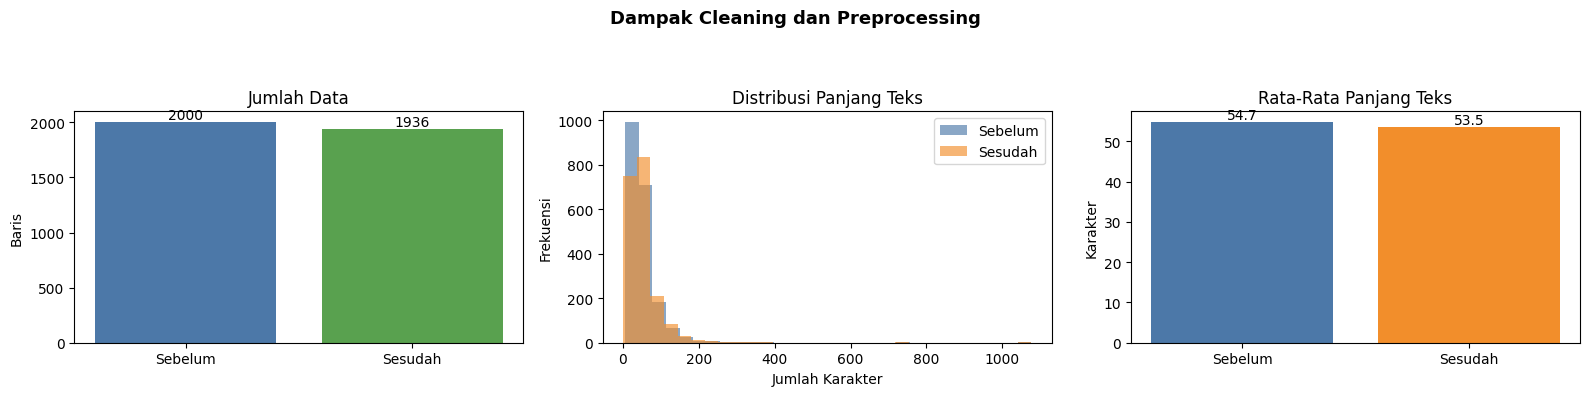

In [4]:
preprocessing_service = PreprocessingService()

clean_df = text_df.filter(
    pl.col(config.COL_TEXT).is_not_null()
    & (pl.col(config.COL_TEXT).str.strip_chars().str.len_chars() > 0)
)
clean_df = dataset_service.deduplicate(clean_df)
processed_df = preprocessing_service.process_dataframe(clean_df)
processed_df = processed_df.filter(
    pl.col(config.COL_PROCESSED).is_not_null()
    & (pl.col(config.COL_PROCESSED).str.strip_chars().str.len_chars() > 0)
)

processed_summary = dataset_service.build_summary(processed_df)
artifact_service.save_dataframe(processed_df, OUTPUT_DATASET_PATH)
dataset_service.export_summary(processed_summary, OUTPUT_SUMMARY_PATH)

print(f"Baris setelah preprocessing: {processed_df.height:,}")
display(processed_df.select(config.COL_ID, config.COL_TEXT, config.COL_PROCESSED, config.COL_ACTUAL_LABEL).head(20))
fig_preprocessing = visualization_service.plot_preprocessing_overview(text_df, processed_df)


## 4. Rule-Based Sentiment


id,processed_text,actual_label,rule_label,rule_score,rule_confidence,rule_hits
"""1""","""barang sesuai pesanan dan cepat sampai""","""positif""","""positif""",2,1.0,"""sesuai, cepat"""
"""2""","""barang bagus harga murah""","""positif""","""positif""",2,1.0,"""bagus, murah"""
"""3""","""paket rapi.mantap.cepat.sampe ke tujuan""","""positif""","""positif""",3,1.0,"""rapi, mantap, cepat"""
"""4""","""ya saya puas dengan barangnya""","""positif""","""positif""",1,1.0,"""puas"""
"""5""","""responya luar biasa b mantap""","""positif""","""positif""",1,1.0,"""mantap"""
"""6""","""seller top, pengiriman cepat barang oke""","""positif""","""positif""",3,1.0,"""top, cepat, oke"""
"""7""","""pengiriman cepat seller top""","""positif""","""positif""",2,1.0,"""cepat, top"""
"""8""","""produk sesuai dengan spec di web dan respon seller sangat cepat. thankyou.""","""positif""","""positif""",2,1.0,"""sesuai, cepat"""
"""9""","""respon super cepat, pengiriman cepat, barang bagus sesuai deskripsi penjual.terima kasih gan""","""positif""","""positif""",4,1.0,"""cepat, cepat, bagus, sesuai"""
"""10""","""barang mantap, pelayanan cepat""","""positif""","""positif""",2,1.0,"""mantap, cepat"""


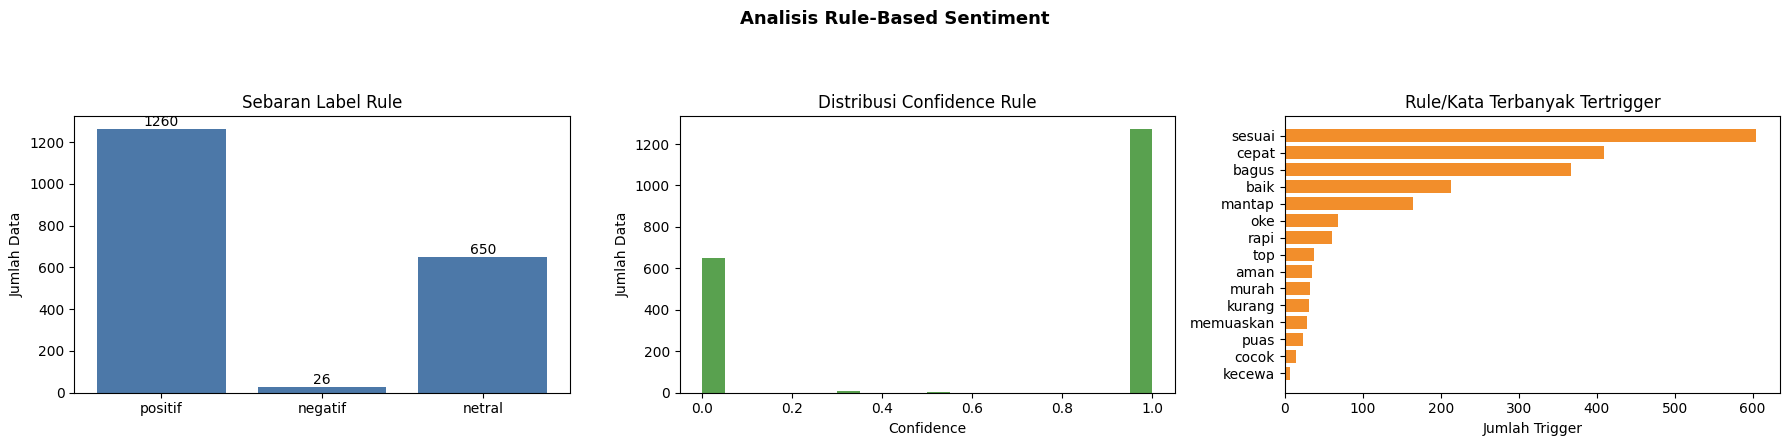

In [5]:
lexicon_service = LexiconSentimentService()
rule_df = lexicon_service.analyze_dataframe(processed_df)

rule_preview = rule_df.select(
    config.COL_ID,
    config.COL_PROCESSED,
    config.COL_ACTUAL_LABEL,
    config.COL_RULE_LABEL,
    "rule_score",
    config.COL_RULE_CONFIDENCE,
    "rule_hits",
)
display(rule_preview.head(25))
fig_rule = visualization_service.plot_rule_sentiment_overview(rule_df)


## 5. Embedding dan Clustering Semantic


id,rule_label,cluster_id,cluster_size,semantic_label,semantic_similarity
"""1""","""positif""",0,27,"""positif""",0.7769
"""2""","""positif""",1,3,"""positif""",0.9077
"""3""","""positif""",-1,1440,"""netral""",0.0
"""4""","""positif""",-1,1440,"""netral""",0.0
"""5""","""positif""",-1,1440,"""netral""",0.0
"""6""","""positif""",-1,1440,"""netral""",0.0
"""7""","""positif""",-1,1440,"""netral""",0.0
"""8""","""positif""",-1,1440,"""netral""",0.0
"""9""","""positif""",7,10,"""positif""",0.8607
"""10""","""positif""",-1,1440,"""netral""",0.0


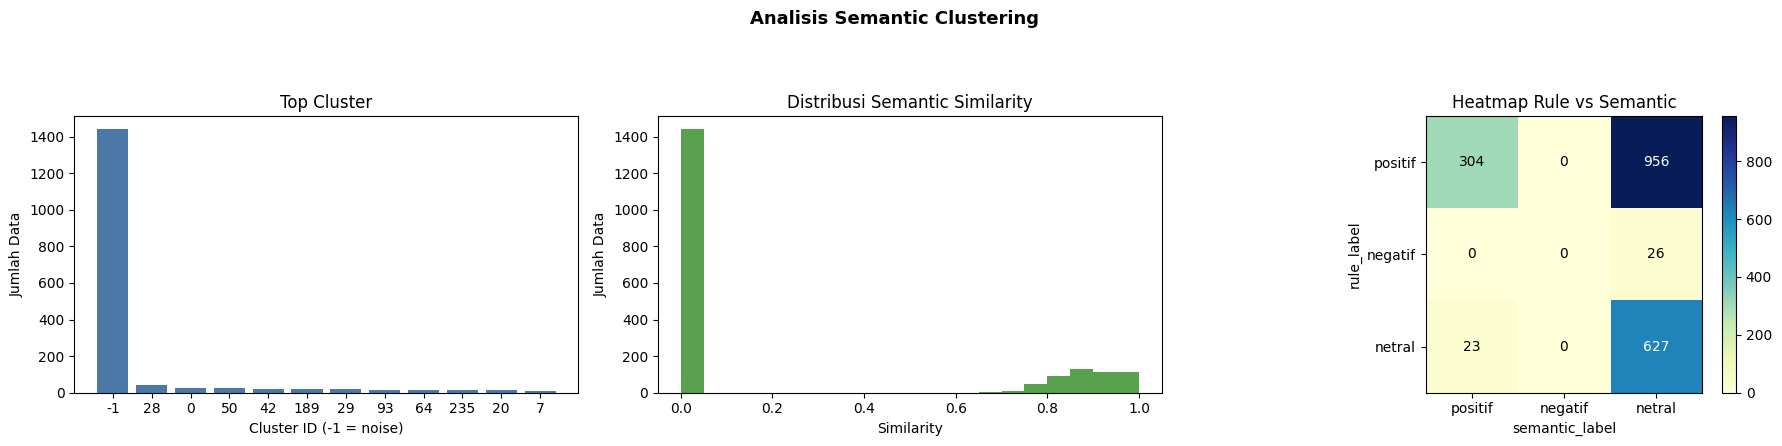

In [6]:
embedding_service = EmbeddingService(backend="hashing")
clustering_service = ClusteringService()

embedded_df, vectors = embedding_service.transform_dataframe(rule_df)
clustered_df = clustering_service.cluster_dataframe(embedded_df, vectors)

cluster_preview = clustered_df.select(
    config.COL_ID,
    config.COL_RULE_LABEL,
    config.COL_CLUSTER_ID,
    "cluster_size",
    config.COL_SEMANTIC_LABEL,
    config.COL_SEMANTIC_SIMILARITY,
)
display(cluster_preview.head(25))
fig_semantic = visualization_service.plot_semantic_overview(clustered_df)

## 6. Ambiguity Detection Tanpa LLM


id,actual_label,rule_label,semantic_label,final_label,is_ambiguous,ambiguity_reason,decision_source
"""1""","""positif""","""positif""","""positif""","""positif""",false,"""""","""automatic"""
"""2""","""positif""","""positif""","""positif""","""positif""",false,"""""","""automatic"""
"""3""","""positif""","""positif""","""netral""","""positif""",true,"""low_semantic_similarity, cluster_noise""","""non_llm_ambiguous"""
"""4""","""positif""","""positif""","""netral""","""positif""",true,"""low_semantic_similarity, cluster_noise""","""non_llm_ambiguous"""
"""5""","""positif""","""positif""","""netral""","""positif""",true,"""low_semantic_similarity, cluster_noise""","""non_llm_ambiguous"""
"""6""","""positif""","""positif""","""netral""","""positif""",true,"""low_semantic_similarity, cluster_noise""","""non_llm_ambiguous"""
"""7""","""positif""","""positif""","""netral""","""positif""",true,"""low_semantic_similarity, cluster_noise""","""non_llm_ambiguous"""
"""8""","""positif""","""positif""","""netral""","""positif""",true,"""low_semantic_similarity, cluster_noise""","""non_llm_ambiguous"""
"""9""","""positif""","""positif""","""positif""","""positif""",false,"""""","""automatic"""
"""10""","""positif""","""positif""","""netral""","""positif""",true,"""low_semantic_similarity, cluster_noise""","""non_llm_ambiguous"""


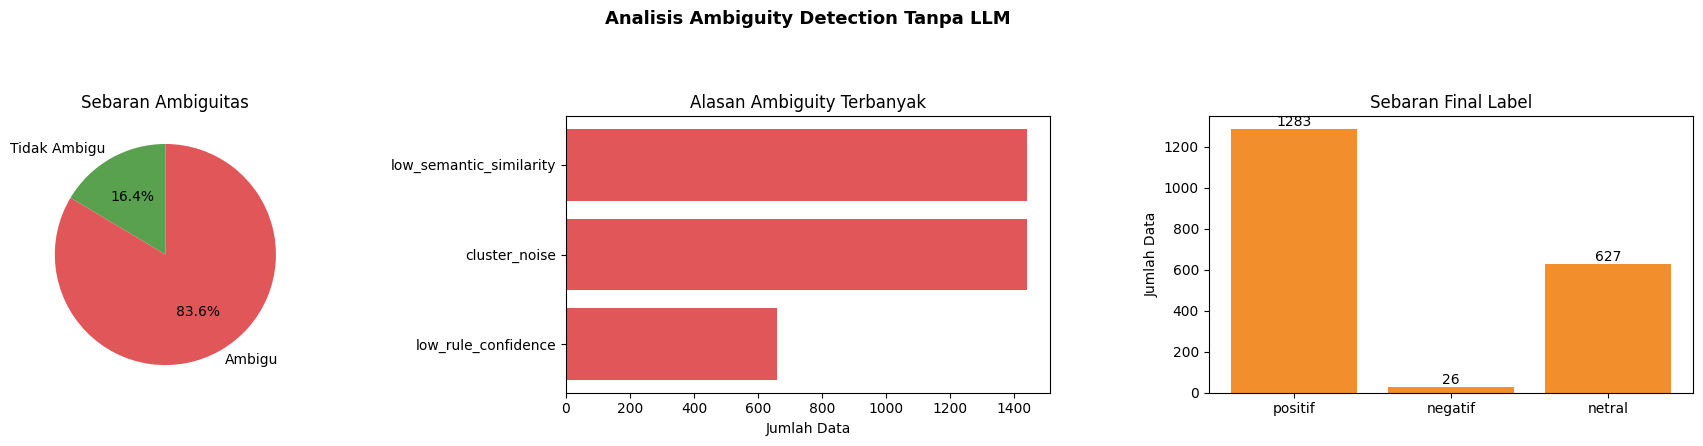

In [7]:
ambiguity_service = AmbiguityService()
final_df = ambiguity_service.decide_dataframe(clustered_df)

ambiguity_preview = final_df.select(
    config.COL_ID,
    config.COL_ACTUAL_LABEL,
    config.COL_RULE_LABEL,
    config.COL_SEMANTIC_LABEL,
    config.COL_FINAL_LABEL,
    config.COL_IS_AMBIGUOUS,
    "ambiguity_reason",
    "decision_source",
)
display(ambiguity_preview.head(25))
fig_ambiguity = visualization_service.plot_ambiguity_overview(final_df)


## 7. Evaluasi Skenario Tanpa LLM


Hasil disimpan: E:\School\tugas-akhir\project\outputs\results\scenario_without_llm.csv
Metrik disimpan: E:\School\tugas-akhir\project\outputs\artifacts\scenario_without_llm_metrics.json


{'total': 1936,
 'accuracy': 0.6705,
 'balanced_accuracy': 0.528,
 'per_label': {'positif': {'precision': 0.9704,
   'recall': 0.6826,
   'support': 1824},
  'negatif': {'precision': 0.4231, 'recall': 0.4074, 'support': 27},
  'netral': {'precision': 0.067, 'recall': 0.4941, 'support': 85}},
 'confusion_matrix': {'positif': {'positif': 1245,
   'negatif': 8,
   'netral': 571},
  'negatif': {'positif': 2, 'negatif': 11, 'netral': 14},
  'netral': {'positif': 36, 'negatif': 7, 'netral': 42}},
 'actual_distribution': {'positif': 1824, 'netral': 85, 'negatif': 27},
 'predicted_distribution': {'positif': 1283, 'netral': 627, 'negatif': 26}}

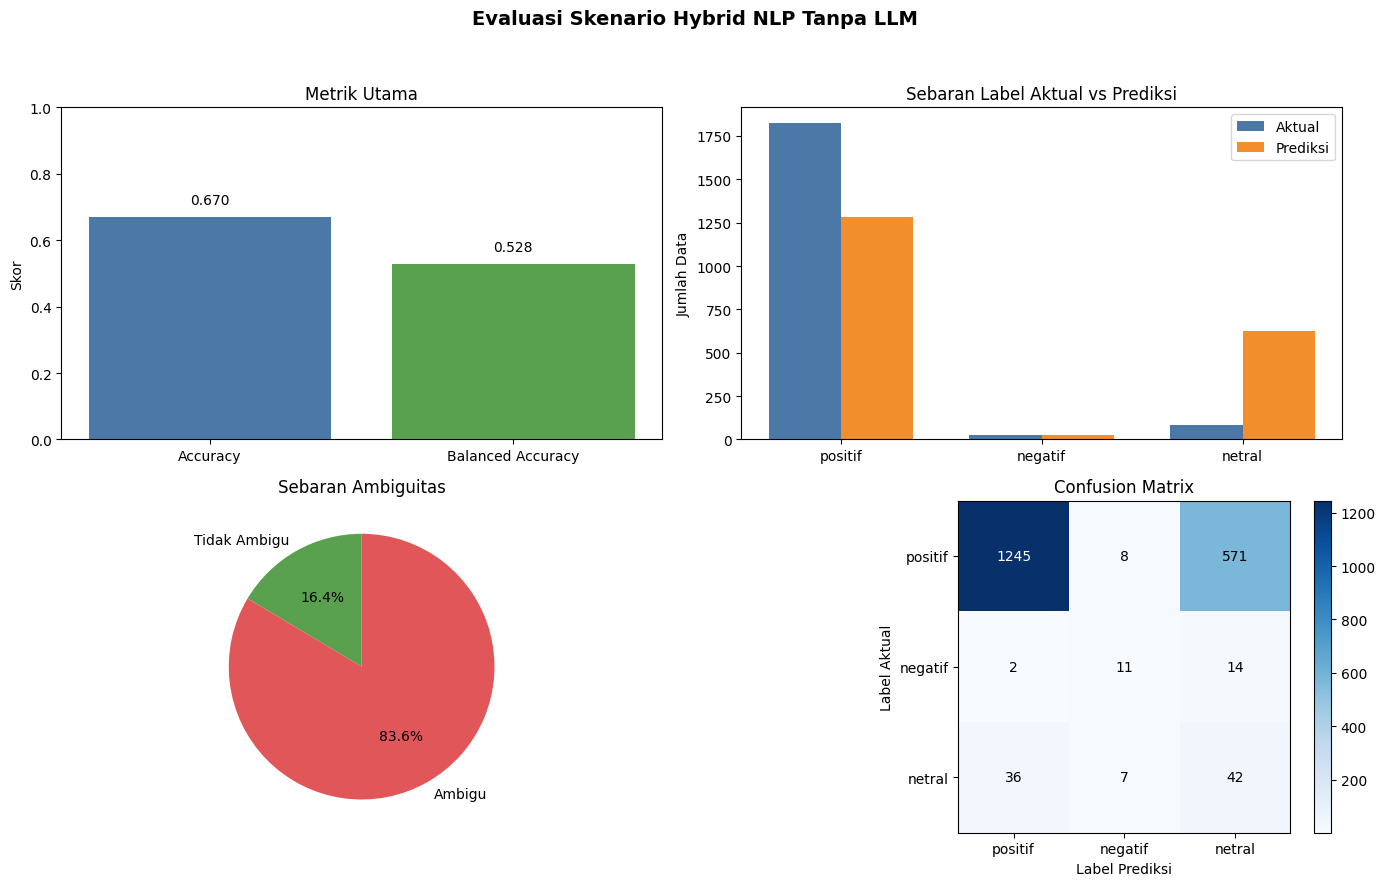

In [8]:
metrics = evaluation_service.evaluate_dataframe(final_df)
artifact_service.save_dataframe(final_df, OUTPUT_RESULTS_PATH)
artifact_service.save_json(metrics, OUTPUT_METRICS_PATH)

print(f"Hasil disimpan: {OUTPUT_RESULTS_PATH}")
print(f"Metrik disimpan: {OUTPUT_METRICS_PATH}")
display(metrics)
fig_evaluation = visualization_service.plot_evaluation_dashboard(final_df, metrics)


## 8. Visualisasi Evaluasi Detail


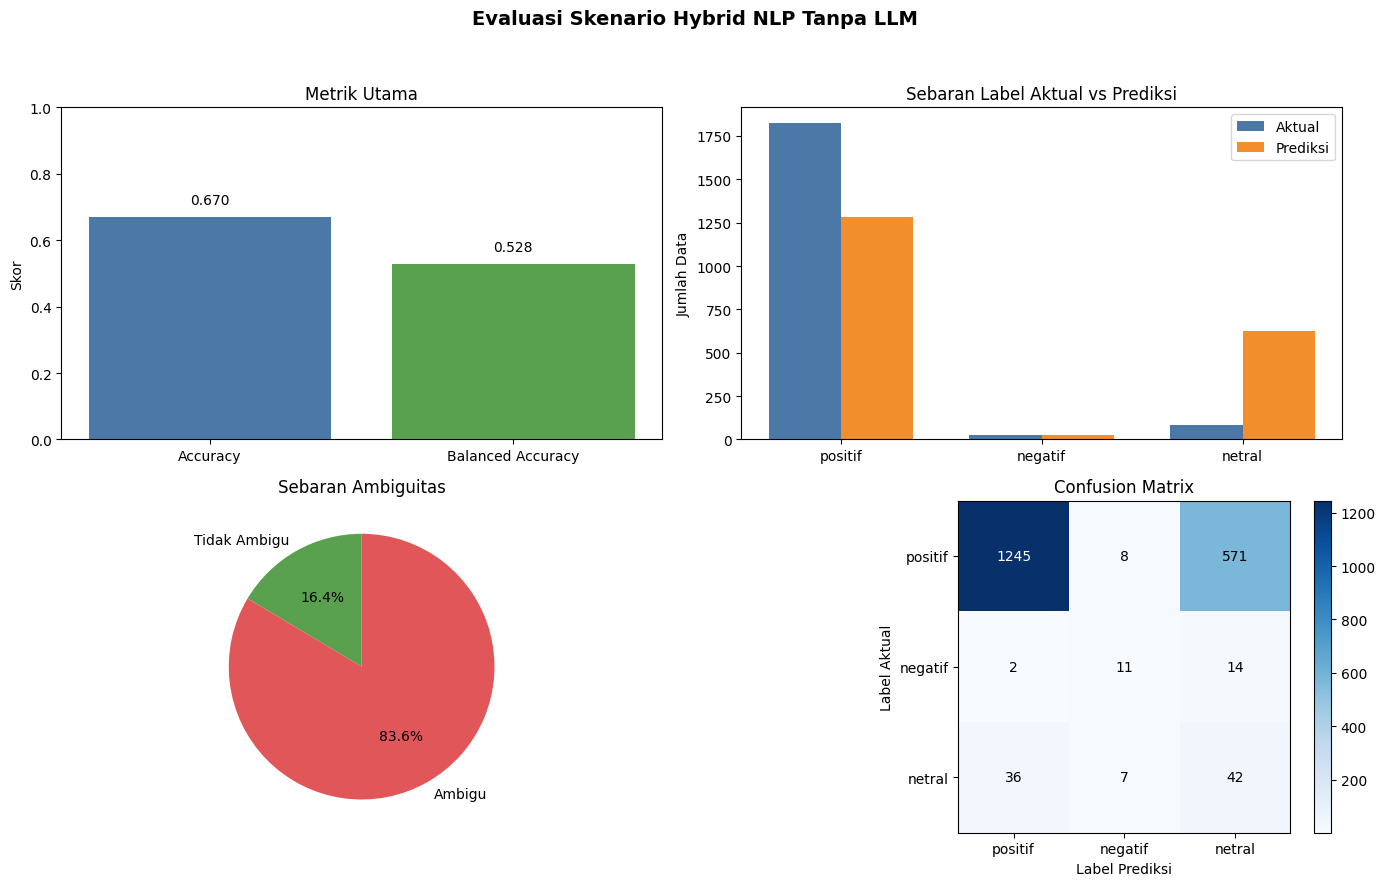

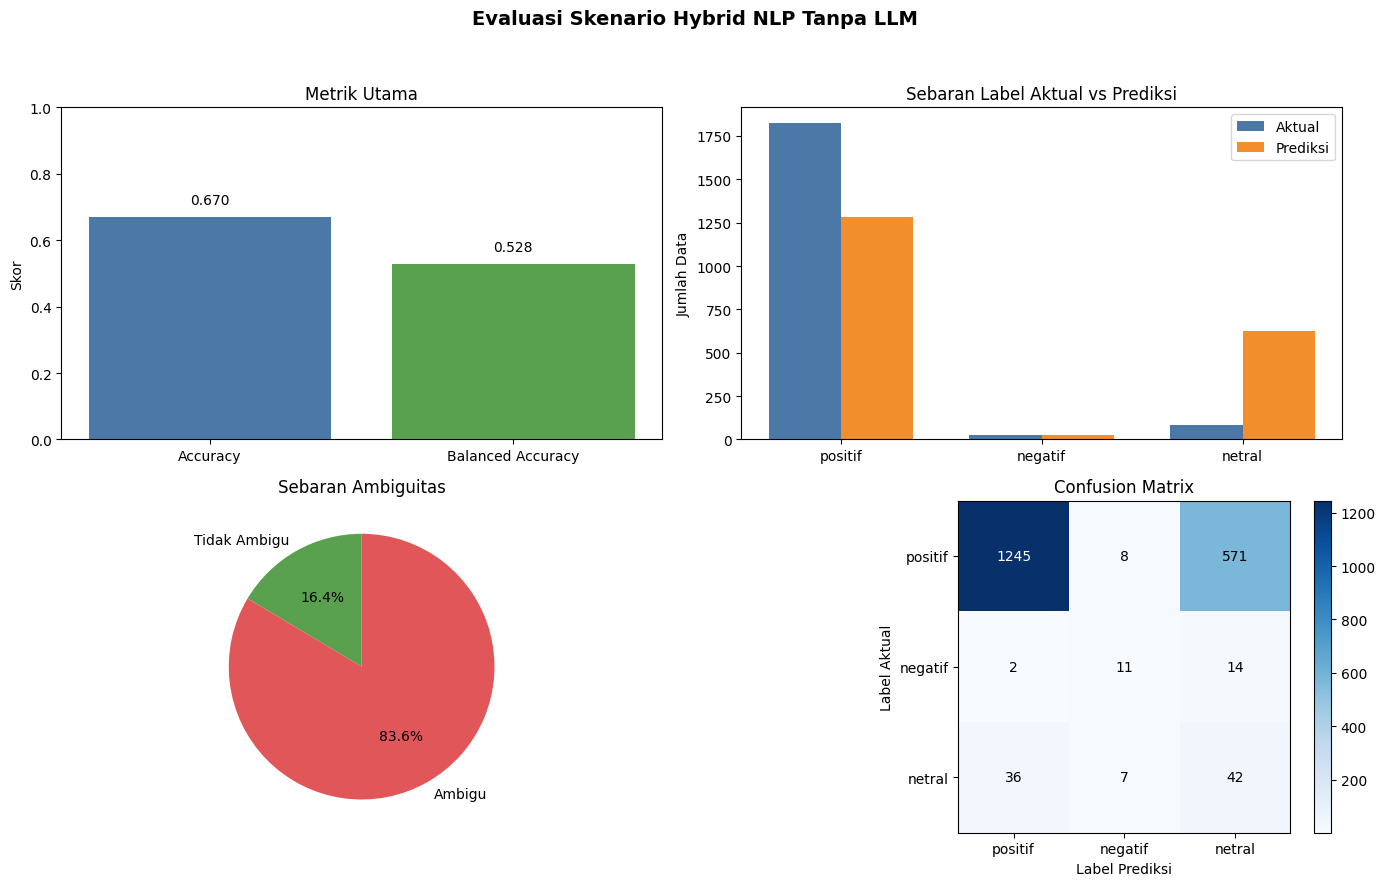

In [9]:
fig_evaluation_detail = visualization_service.plot_evaluation_dashboard(final_df, metrics)
fig_evaluation_detail


## 9. Ringkasan Distribusi


In [10]:
final_df.group_by(
    config.COL_ACTUAL_LABEL,
    config.COL_FINAL_LABEL,
    config.COL_IS_AMBIGUOUS,
).agg(pl.len().alias("count")).sort(
    config.COL_ACTUAL_LABEL,
    config.COL_FINAL_LABEL,
    config.COL_IS_AMBIGUOUS,
)


actual_label,final_label,is_ambiguous,count
"""negatif""","""negatif""",true,11
"""negatif""","""netral""",true,14
"""negatif""","""positif""",true,2
"""netral""","""negatif""",true,7
"""netral""","""netral""",true,42
"""netral""","""positif""",false,5
"""netral""","""positif""",true,31
"""positif""","""negatif""",true,8
"""positif""","""netral""",true,571
"""positif""","""positif""",false,313
